# Bootstrap Fold Test on Osler Volcanic Group Data

## Introduction

This notebook conducts a bootstrap fold test (Tauxe and Watson, 1994) on reversed polarity paleomagnetic data from the Osler Volcanic Group using PmagPy. The analysis combines data from two studies in the MagIC database:

> Halls, H. (1974). A paleomagnetic reversal in the Osler Volcanic Group, northern Lake Superior. *Can. J. Earth Sci.*, 11, 1200–1207. doi:[10.1139/e74-113](https://doi.org/10.1139/e74-113)

> Swanson-Hysell, N. L., Vaughan, A. A., Mustain, M. R., and Asp, K. E. (2014). Confirmation of progressive plate motion during the Midcontinent Rift's early magmatic stage from the Osler Volcanic Group, Ontario, Canada. *Geochem. Geophys. Geosyst.*, 15, 2039–2047. doi:[10.1002/2013GC005180](https://doi.org/10.1002/2013GC005180)

The Osler Volcanic Group is a sequence of ca. 1108–1105 Ma basalt flows erupted during the Midcontinent Rift exposed along the north shore of Lake Superior. The flows have been tilted to varying degrees, providing an opportunity to test whether the remanent magnetization was acquired before tilting (a positive fold test) or after tilting (a negative fold test).

Following the approach of Tauxe et al. (2016), we combine the reversed polarity flows from Halls (1974) at Nipigon Strait with the upper portion of the Simpson Island section from Swanson-Hysell et al. (2014) which are temporally equivalent. The varying bedding attitudes across these sites provide the structural diversity needed for a meaningful fold test.

### References

- Tauxe, L. and Watson, G. S. (1994). The fold test: an eigen analysis approach. *Earth Planet. Sci. Lett.*, 122, 331–341. doi:[10.1016/0012-821X(94)90006-X](https://doi.org/10.1016/0012-821X(94)90006-X)
- Tauxe, L., Shaar, R., Jonestrask, L., Swanson-Hysell, N. L., et al. (2016). PmagPy: Software package for paleomagnetic data analysis and a bridge to the Magnetics Information Consortium (MagIC) Database. *Geochem. Geophys. Geosyst.*, 17, 2450–2463. doi:[10.1002/2016GC006307](https://doi.org/10.1002/2016GC006307)

In [1]:
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Download and unpack data from MagIC

We download the two MagIC contributions using their contribution IDs and unpack them into separate directories. The `ipmag.download_magic_from_id()` function retrieves the contribution file from the MagIC database, and `ipmag.unpack_magic()` splits the combined file into separate MagIC table files (locations.txt, sites.txt, samples.txt, etc.).

In [2]:
# Halls (1974) — Nipigon Strait reversed and normal flows
halls_dir = './data/Halls1974'
result, halls_file = ipmag.download_magic_from_id('20260', directory=halls_dir)
ipmag.unpack_magic(halls_file, dir_path=halls_dir, print_progress=False)

Download successful. File saved to: ./data/Halls1974/magic_contribution_20260.txt
1  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/Halls1974/contribution.txt
2  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/Halls1974/locations.txt
60  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/Halls1974/sites.txt


True

In [3]:
# Swanson-Hysell et al. (2014) — Simpson Island section
sh_dir = './data/SwansonHysell2014'
result, sh_file = ipmag.download_magic_from_id('18693', directory=sh_dir)
ipmag.unpack_magic(sh_file, dir_path=sh_dir, print_progress=False)

Download successful. File saved to: ./data/SwansonHysell2014/magic_contribution_18693.txt
1  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/contribution.txt
6  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/locations.txt
345  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/sites.txt
1301  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/samples.txt
667  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/specimens.txt
13395  records written to file  /Users/hematite/Documents/GitHub/PmagPy-docs/example_notebooks/template_notebooks/data/SwansonHysell2014/measurements.txt
89  records writt

True

## Load and filter the Halls (1974) data

Halls (1974) studied flows from the Osler Volcanic Group at Nipigon Strait. The lower portion of the section records reversed polarity and the upper portion records normal polarity — demonstrating a paleomagnetic reversal within the volcanic sequence. We use only the reversed polarity flows (`Lower Reversed`) in geographic coordinates (`dir_tilt_correction == 0`) for the fold test.

In this contribution, the bedding orientations (`bed_dip`, `bed_dip_direction`) are on the same rows as the directional data in the sites table, so no merging is needed.

In [4]:
halls_sites = pd.read_csv(halls_dir + '/sites.txt', sep='\t', header=1)

# filter for reversed polarity flows in geographic coordinates
halls_geo = halls_sites[(halls_sites.dir_tilt_correction == 0) &
                        (halls_sites.location.str.contains('Lower Reversed'))].copy()

print(f'{len(halls_geo)} reversed sites from Halls (1974)')
halls_geo[['site', 'dir_dec', 'dir_inc', 'bed_dip_direction', 'bed_dip']].head()

25 reversed sites from Halls (1974)


,site,dir_dec,dir_inc,bed_dip_direction,bed_dip
11,6,112.6,-18.1,131.0,28
13,7,124.5,-45.3,149.0,20
15,8,144.3,-47.0,150.0,18
17,9,121.0,-39.1,145.0,20
19,10,129.7,-12.1,134.0,30


## Load and filter the Swanson-Hysell et al. (2014) data

Swanson-Hysell et al. (2014) studied flows from multiple stratigraphic sections on Simpson Island. Following the approach of Tauxe et al. (2016), we filter for the upper third of the Simpson Island stratigraphy (`height > 2082` m) which is temporally equivalent to the reversed flows from Halls (1974).

In this contribution, the bedding orientations are only populated on the metadata rows for each site (method code `GE-WGS84`) and are missing from the directional data rows. We propagate the bedding values across all rows for each site so that the directional rows have the bedding information they need for the fold test.

In [5]:
sh_sites = pd.read_csv(sh_dir + '/sites.txt', sep='\t', header=1)

# propagate bedding values to all rows for each site
sh_sites[['bed_dip', 'bed_dip_direction']] = (
    sh_sites.groupby('site')[['bed_dip', 'bed_dip_direction']].transform('first')
)

# filter for geographic coordinates in the upper third of the section
sh_geo = sh_sites[(sh_sites.dir_tilt_correction == 0) &
                  (sh_sites.dir_dec.notna()) &
                  (sh_sites.height > 2082)].copy()

print(f'{len(sh_geo)} upper third sites from Swanson-Hysell et al. (2014)')
sh_geo[['site', 'height', 'dir_dec', 'dir_inc', 'bed_dip_direction', 'bed_dip']].head()

34 upper third sites from Swanson-Hysell et al. (2014)


,site,height,dir_dec,dir_inc,bed_dip_direction,bed_dip
130,SI4(106.0 to 121.4),2089.0,140.0,-46.6,187.0,18.0
134,SI4(121.4 to 127.3),2104.4,129.6,-43.6,187.0,18.0
142,SI4(133.8 to 143.1),2116.8,134.8,-52.7,187.0,18.0
146,SI4(160.4 to 171.1),2143.4,163.7,-46.6,187.0,18.0
170,SI5a(0.0 to 9.0),3115.0,133.7,-45.7,193.0,19.0


## Combine datasets and build the fold test data array

The function `ipmag.bootstrap_fold_test()` expects a numpy array with columns `[dec, inc, dip_direction, dip]` where the directional data are in geographic coordinates (uncorrected for bedding tilt). We extract these four columns from each dataset and concatenate them.

In [6]:
cols = ['dir_dec', 'dir_inc', 'bed_dip_direction', 'bed_dip']

halls_diddd = halls_geo[cols].values
sh_diddd = sh_geo[cols].values

# combine the two datasets
diddd = np.concatenate([halls_diddd, sh_diddd])
print(f'Combined data array: {len(halls_diddd)} Halls (1974) + '
      f'{len(sh_diddd)} Swanson-Hysell et al. (2014) = {len(diddd)} total sites')
print(f'Array shape: {diddd.shape}')

Combined data array: 25 Halls (1974) + 34 Swanson-Hysell et al. (2014) = 59 total sites
Array shape: (59, 4)


## Visualize the combined directions

Before running the fold test, we can plot the combined dataset in both geographic (in situ) and tilt-corrected coordinates to visually assess whether tilt correction improves the clustering of directions.

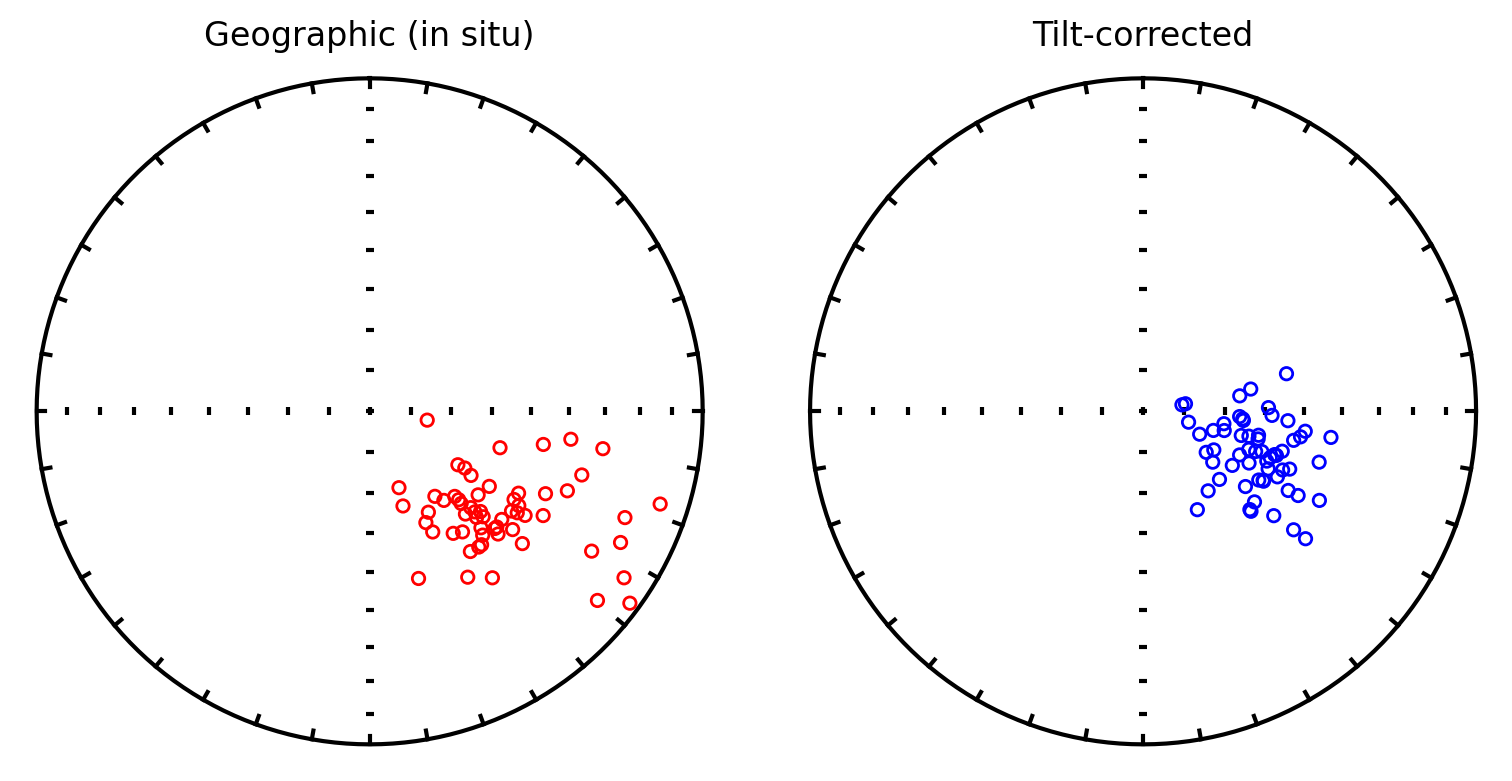

In [7]:
# get tilt-corrected directions for comparison
halls_tc = halls_sites[(halls_sites.dir_tilt_correction == 100) &
                       (halls_sites.location.str.contains('Lower Reversed'))].copy()

sh_tc = sh_sites[(sh_sites.dir_tilt_correction == 100) &
                 (sh_sites.dir_dec.notna()) &
                 (sh_sites.height > 2082)].copy()

# combine in situ and tilt-corrected dec/inc lists
combined_dec_is = np.concatenate([halls_geo.dir_dec.values, sh_geo.dir_dec.values])
combined_inc_is = np.concatenate([halls_geo.dir_inc.values, sh_geo.dir_inc.values])
combined_dec_tc = np.concatenate([halls_tc.dir_dec.values, sh_tc.dir_dec.values])
combined_inc_tc = np.concatenate([halls_tc.dir_inc.values, sh_tc.dir_inc.values])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

plt.sca(axes[0])
ipmag.plot_net()
ipmag.plot_di(combined_dec_is, combined_inc_is, color='r')
plt.title('Geographic (in situ)')

plt.sca(axes[1])
ipmag.plot_net()
ipmag.plot_di(combined_dec_tc, combined_inc_tc, color='b')
plt.title('Tilt-corrected')

plt.tight_layout()
plt.show()

## Compare Fisher means and precision

The ratio of the precision parameter $k$ before and after tilt-correction ($k_2$/$k_1$) provides a qualitative assessment of whether tilt correction improves the grouping of directions. This ratio was at the heart of the McElhinny (1964) fold test, although that test has been shown to not be statistically robust (McFadden, 1990). We calculate it here for reference before applying the more rigorous bootstrap fold test.

In [8]:
is_mean = ipmag.fisher_mean(combined_dec_is.tolist(), combined_inc_is.tolist())
tc_mean = ipmag.fisher_mean(combined_dec_tc.tolist(), combined_inc_tc.tolist())

print("Fisher mean of in situ (geographic) directions:")
ipmag.print_direction_mean(is_mean)
print('')
print("Fisher mean of tilt-corrected directions:")
ipmag.print_direction_mean(tc_mean)
print('')
print(f"k2/k1 ratio: {tc_mean['k']/is_mean['k']:.2f}")

Fisher mean of in situ (geographic) directions:
Dec: 128.3  Inc: -47.6
Number of directions in mean (n): 59
Angular radius of 95% confidence (a_95): 4.2
Precision parameter (k) estimate: 19.9

Fisher mean of tilt-corrected directions:
Dec: 110.9  Inc: -59.9
Number of directions in mean (n): 59
Angular radius of 95% confidence (a_95): 2.8
Precision parameter (k) estimate: 43.9

k2/k1 ratio: 2.20


## Run the bootstrap fold test

The Tauxe and Watson (1994) bootstrap fold test finds the degree of unfolding that produces the tightest grouping of directions using the eigenvalue $\tau_1$ as the criterion. The procedure generates bootstrap pseudo-samples from the data, applies varying percentages of untilting (0% = geographic, 100% = full tilt correction), and tracks $\tau_1$ at each step. If the 95% confidence bounds on the percent unfolding that maximizes $\tau_1$ enclose 100%, the data pass the fold test — indicating that the magnetization was acquired before tilting.

Three plots are generated:
1. Equal area plot of geographic (uncorrected) data
2. Equal area plot of tilt-corrected data
3. Bootstrap results showing eigenvalue trends for pseudo-samples (red dashed), the CDF of the eigenvalue maximum (green), and 95% confidence bounds (dashed verticals)

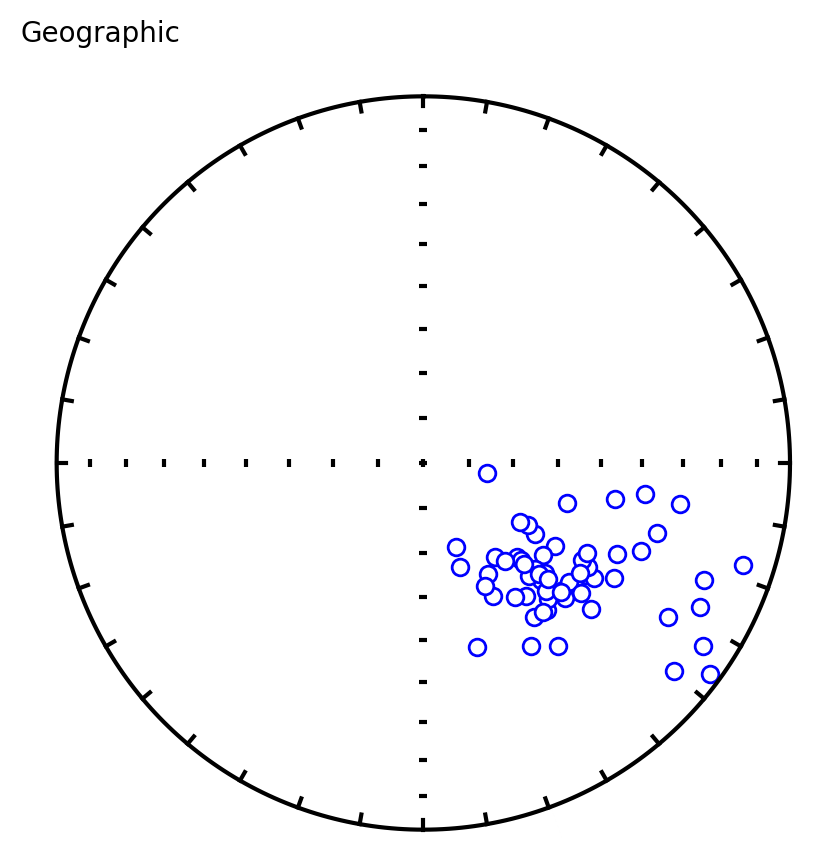

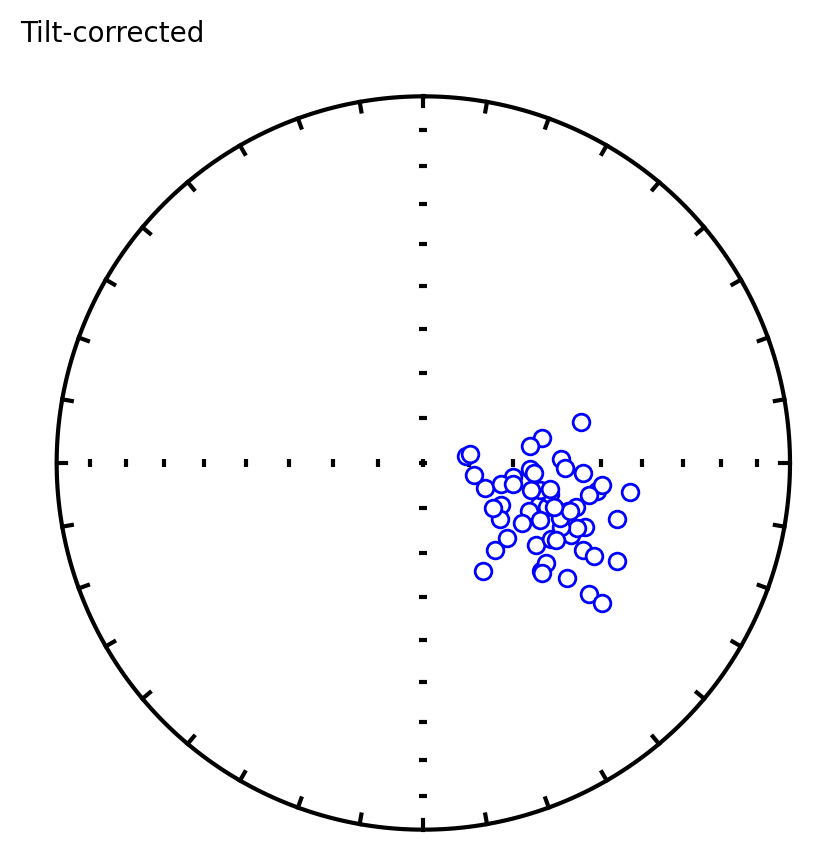

doing  1000  iterations...please be patient.....

tightest grouping of vectors obtained at (95% confidence bounds):
100 - 134 percent unfolding
range of all bootstrap samples: 
64  -  139 percent unfolding


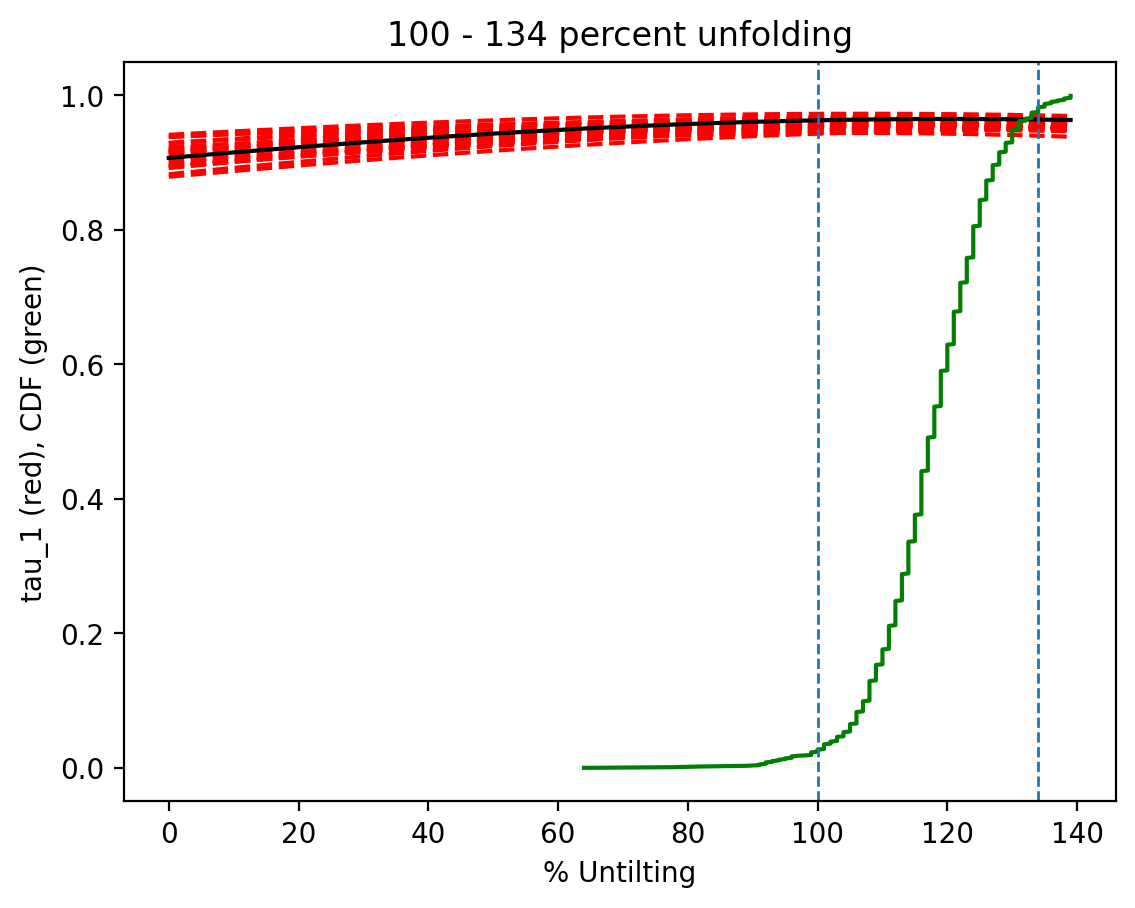

In [9]:
ipmag.bootstrap_fold_test(diddd, num_sims=1000, min_untilt=0, max_untilt=140)